# Hydrogen Facility Operations Introduction
[![hydrogen_operations.ipynb](https://img.shields.io/badge/github-%23121011.svg?logo=github)](https://github.com/ampl/colab.ampl.com/blob/master/authors/eduardosalaz/hydrogen/hydrogen_operations.ipynb) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ampl/colab.ampl.com/blob/master/authors/eduardosalaz/hydrogen/hydrogen_operations.ipynb) [![Open In Deepnote](https://deepnote.com/buttons/launch-in-deepnote-small.svg)](https://deepnote.com/launch?url=https://github.com/ampl/colab.ampl.com/blob/master/authors/eduardosalaz/hydrogen/hydrogen_operations.ipynb) [![Open In Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ampl/colab.ampl.com/blob/master/authors/eduardosalaz/hydrogen/hydrogen_operations.ipynb) [![Open In Gradient](https://assets.paperspace.io/img/gradient-badge.svg)](https://console.paperspace.com/github/ampl/colab.ampl.com/blob/master/authors/eduardosalaz/hydrogen/hydrogen_operations.ipynb) [![Open In SageMaker Studio Lab](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/ampl/colab.ampl.com/blob/master/authors/eduardosalaz/hydrogen/hydrogen_operations.ipynb) [![Powered by AMPL](https://h.ampl.com/https://github.com/ampl/colab.ampl.com/blob/master/authors/eduardosalaz/hydrogen/hydrogen_operations.ipynb)](https://ampl.com)

Description: A notebook that demonstrates the optimization of a green hydrogen production facility that must navigate the complex interplay between variable renewable energy supply, fluctuating electricity prices, multiple market segments, and operational constraints.

Tags: educational, gurobi, energy, hydrogen, mp

Notebook author: Eduardo Salazar <<eduardo@ampl.com>>

Model author: Eduardo Salazar <<eduardo@ampl.com>>


In [1]:
# Install dependencies
%pip install -q amplpy pandas numpy matplotlib seaborn

In [2]:
# Google Colab & Kaggle integration
from amplpy import AMPL, ampl_notebook

ampl = ampl_notebook(
    modules=["gurobi"],  # modules to install
    license_uuid="default",  # license to use
)  # instantiate AMPL object and register magics

# Green Hydrogen Production Optimization: Balancing Renewable Energy and Market Demands

## The Business Challenge
As the world transitions to clean energy, green hydrogen has emerged as a critical energy carrier for hard-to-decarbonize sectors. However, producing hydrogen profitably from renewable sources presents several challenges:

1. **Intermittent Supply**: Solar and wind generation don't align with demand
2. **Market Complexity**: Multiple customer types with different price sensitivities
3. **Operational Constraints**: Electrolyzers can't cycle freely without degradation
4. **Certification Requirements**: Must maintain >90% renewable content for "green" certification

Our facility operates two electrolyzers (15 MW and 8 MW) powered by on-site renewables with grid backup, serving contracted industrial customers while capitalizing on spot market opportunities.

## Limitations and Assumptions
The model was thought of as a rolling horizon operational model, where the input data of the demand and forecasted generation is updated daily and solved, thus the hours are set to 24.

Only two electrolyzer units were installed in the facility, tipically one would find more units.

The energy forecast is perfect and has no errors, in real life, forecasts are not perfect. A future enhancement would be taking into account this error to make a stochastic optimization problem, hydrogen prices are also forecasted with no error.

There are energy costs associated with compressing hydrogen in the storage tank, in this model they are omitted, and although an hourly leakage factor was introduced, a more complex loss model may be introduced.

Water availability is not taken into account, an endless supply is assumed.

No wear on equipment is modelled as well, in real life, the operation cycles introduce damage to the storage tank and electrolyzers

The model assumes the facility is a price-taker with no market impact. In reality, large-scale H2 production could influence local electricity prices and hydrogen market dynamics.

Transmission network constraints and congestion are not modeled. The grid connection is assumed to always accommodate the requested import/export flows.


Electrolyzers are modeled as reaching full efficiency instantly when turned on. Real units have warm-up periods and transient behaviors.

All hydrogen delivery is assumed to occur at the production site with no transportation time or costs.





In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle, FancyBboxPatch
from matplotlib.gridspec import GridSpec
import numpy as np
from datetime import datetime

## Model Setup and Data Generation

### Facility Configuration
We model a 23 MW green hydrogen facility with:
- **Large Electrolyzer (15 MW)**: Higher efficiency but less flexible operations
- **Small Electrolyzer (8 MW)**: Lower efficiency but rapid response capability
- **Renewable Generation**:
  - Solar: 10 MW nameplate capacity (peaks at noon, zero at night)
  - Wind: 15 MW nameplate capacity (typically 20-80% capacity factor)
- **Storage System**: 1200 kg capacity with 10% hourly losses from compression

Note: The 25 MW of renewable nameplate capacity doesn't mean 25 MW of continuous power. Due to variability, average generation is approximately 8-10 MW, creating the fundamental challenge this optimization addresses.

### Market Structure
The facility participates in three hydrogen markets:
1. **Contract Deliveries**: Fixed price (\$3/kg) with penalties for non-delivery (\$5/kg)
2. **Spot Market**: Variable prices (\$2.50-3.50/kg) with limited liquidity
3. **Base Industrial**: Flexible demand at 90% of spot prices

Let's examine the input data patterns that drive our optimization:

In [4]:
# Time periods (24 hours)
hours = list(range(24))

# Electricity prices ($/MWh)
base_price = 50
price_profile = [
    0.7,
    0.6,
    0.6,
    0.6,
    0.7,
    0.8,  # Night (0-5)
    0.9,
    1.1,
    1.3,
    1.2,
    1.1,
    1.0,  # Morning peak (6-11)
    0.9,
    0.9,
    1.0,
    1.1,
    1.3,
    1.4,  # Afternoon to evening peak (12-17)
    1.3,
    1.1,
    0.9,
    0.8,
    0.7,
    0.7,  # Evening to night (18-23)
]
electricity_prices = [base_price * p for p in price_profile]

# Solar and wind generation
solar_capacity = 10
solar_profile = [
    0,
    0,
    0,
    0,
    0,
    0.1,
    0.3,
    0.5,
    0.7,
    0.85,
    0.95,
    1.0,
    1.0,
    0.95,
    0.85,
    0.7,
    0.5,
    0.3,
    0.1,
    0,
    0,
    0,
    0,
    0,
]
solar_generation = [solar_capacity * s for s in solar_profile]

wind_capacity = 15
np.random.seed(42)
wind_base = [
    0.3,
    0.4,
    0.5,
    0.4,
    0.3,
    0.3,
    0.2,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.7,
    0.6,
    0.5,
    0.4,
    0.4,
    0.5,
    0.6,
    0.5,
    0.4,
    0.3,
]
wind_generation = [wind_capacity * (w + 0.1 * np.random.randn()) for w in wind_base]
wind_generation = [max(0, min(wind_capacity, w)) for w in wind_generation]

# Electrolyzer specifications
electrolyzers = {
    "Large": {
        "capacity": 15,
        "min_load": 0.3,
        "startup_cost": 500,
        "shutdown_cost": 200,
        "min_uptime": 3,
        "min_downtime": 2,
        "ramp_limit": 5,
    },
    "Small": {
        "capacity": 8,
        "min_load": 0.2,
        "startup_cost": 50,
        "shutdown_cost": 50,
        "min_uptime": 1,
        "min_downtime": 1,
        "ramp_limit": 4,
    },
}

# Efficiency breakpoints
efficiency_breakpoints = {
    "Large": {
        "load": [0.0, 0.3, 0.5, 0.75, 1.0],
        "efficiency": [0.0, 0.65, 0.68, 0.715, 0.75],
    },
    "Small": {
        "load": [0.0, 0.2, 0.5, 0.75, 1.0],
        "efficiency": [0.0, 0.67, 0.70, 0.71, 0.72],
    },
}

# System parameters
h2_energy_content = 33.33  # Physical constant
o2_h2_ratio = 8  # Physical constant
oxygen_price = 0.05  # Estimated parameter but within bounds of real life O2 price
storage_capacity = 500  # 500 Kg hydrogen tank
initial_storage = 0  # Empty reserves, can change this to account for previous state
min_storage = 50  # Should at least keep 50 kg
storage_loss_rate = 0.001  # Each hour some leaks occur
grid_import_limit = 5  # Limit of 5 MW of import/export per hour
grid_export_limit = 5
grid_export_price = 0.9  # Energy sold back to the grid has a 0.9 penalty

# Demands and prices
base_demand = [
    5,
    5,
    5,
    5,
    5,
    10,
    15,
    20,
    25,
    25,
    20,
    20,
    20,
    20,
    20,
    25,
    25,
    20,
    15,
    10,
    5,
    5,
    5,
    5,
]

contract_demand = [
    0,
    0,
    0,
    0,
    0,
    0,
    25,
    30,
    35,
    40,
    45,
    45,
    50,
    55,
    60,
    55,
    45,
    30,
    20,
    20,
    10,
    0,
    0,
    0,
]

h2_spot_prices = [
    2.5,
    2.5,
    2.5,
    2.5,
    2.5,
    2.8,
    3.0,
    3.2,
    3.5,
    3.5,
    3.2,
    3.0,
    3.0,
    3.0,
    3.0,
    3.2,
    3.5,
    3.2,
    3.0,
    2.8,
    2.5,
    2.5,
    2.5,
    2.5,
]

contract_price = 3.0
penalty_price = 5.0

contract_demand = [
    d * 3 for d in contract_demand
]  # Multiplication factor allows for sensitivity analysis on demand
base_demand = [d * 5 for d in base_demand]


print(f"Total daily contract demand: {sum(contract_demand)} kg")
print(f"Total daily base demand: {sum(base_demand)} kg")

Total daily contract demand: 1695 kg
Total daily base demand: 1675 kg


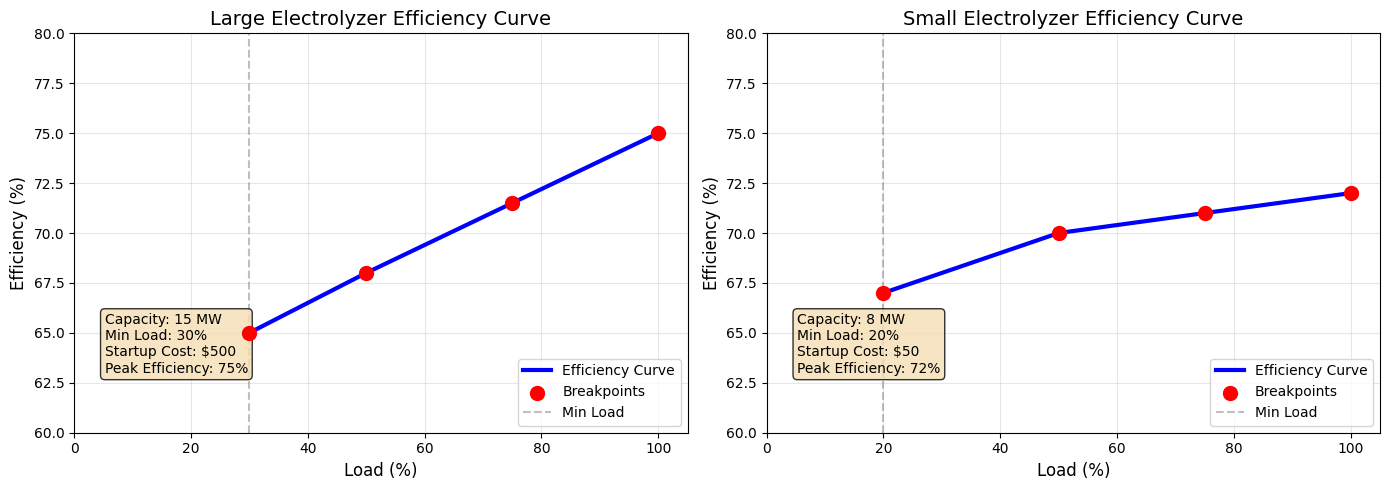

In [5]:
def plot_efficiency_curves():
    """Visualize the efficiency curves for both electrolyzers using the breakpoints"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for idx, (name, elec) in enumerate(electrolyzers.items()):
        ax = ax1 if idx == 0 else ax2

        # Get efficiency breakpoints for this unit
        load_points = efficiency_breakpoints[name]["load"]
        eff_points = efficiency_breakpoints[name]["efficiency"]

        # Create smooth curve by interpolating between breakpoints
        loads_smooth = np.linspace(elec["min_load"], 1.0, 100)
        efficiency_smooth = np.interp(
            loads_smooth, load_points[1:], eff_points[1:]
        )  # Skip the 0,0 point

        # Plot the smooth curve
        ax.plot(
            loads_smooth * 100,
            efficiency_smooth * 100,
            "b-",
            linewidth=3,
            label="Efficiency Curve",
        )

        # Plot the actual breakpoints (skip the 0,0 point for visibility)
        ax.scatter(
            [p * 100 for p in load_points[1:]],
            [e * 100 for e in eff_points[1:]],
            color="red",
            s=100,
            zorder=5,
            label="Breakpoints",
        )

        # Add vertical line at minimum load
        ax.axvline(
            x=elec["min_load"] * 100,
            color="gray",
            linestyle="--",
            alpha=0.5,
            label="Min Load",
        )

        ax.set_xlabel("Load (%)", fontsize=12)
        ax.set_ylabel("Efficiency (%)", fontsize=12)
        ax.set_title(f"{name} Electrolyzer Efficiency Curve", fontsize=14)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 105)
        ax.set_ylim(60, 80)
        ax.legend(loc="lower right")

        # Add text box with key specs
        textstr = f'Capacity: {elec["capacity"]} MW\n'
        textstr += f'Min Load: {elec["min_load"]*100:.0f}%\n'
        textstr += f'Startup Cost: ${elec["startup_cost"]}\n'
        textstr += f"Peak Efficiency: {eff_points[-1]*100:.0f}%"
        props = dict(boxstyle="round", facecolor="wheat", alpha=0.8)
        ax.text(
            0.05,
            0.30,
            textstr,
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment="top",
            bbox=props,
        )

    plt.tight_layout()
    plt.show()


# Call the function
plot_efficiency_curves()

### Key Insight: Non-Linear Efficiency Curves
The optimization must balance throughput versus efficiency while respecting minimum load constraints (30% for Large, 20% for Small).

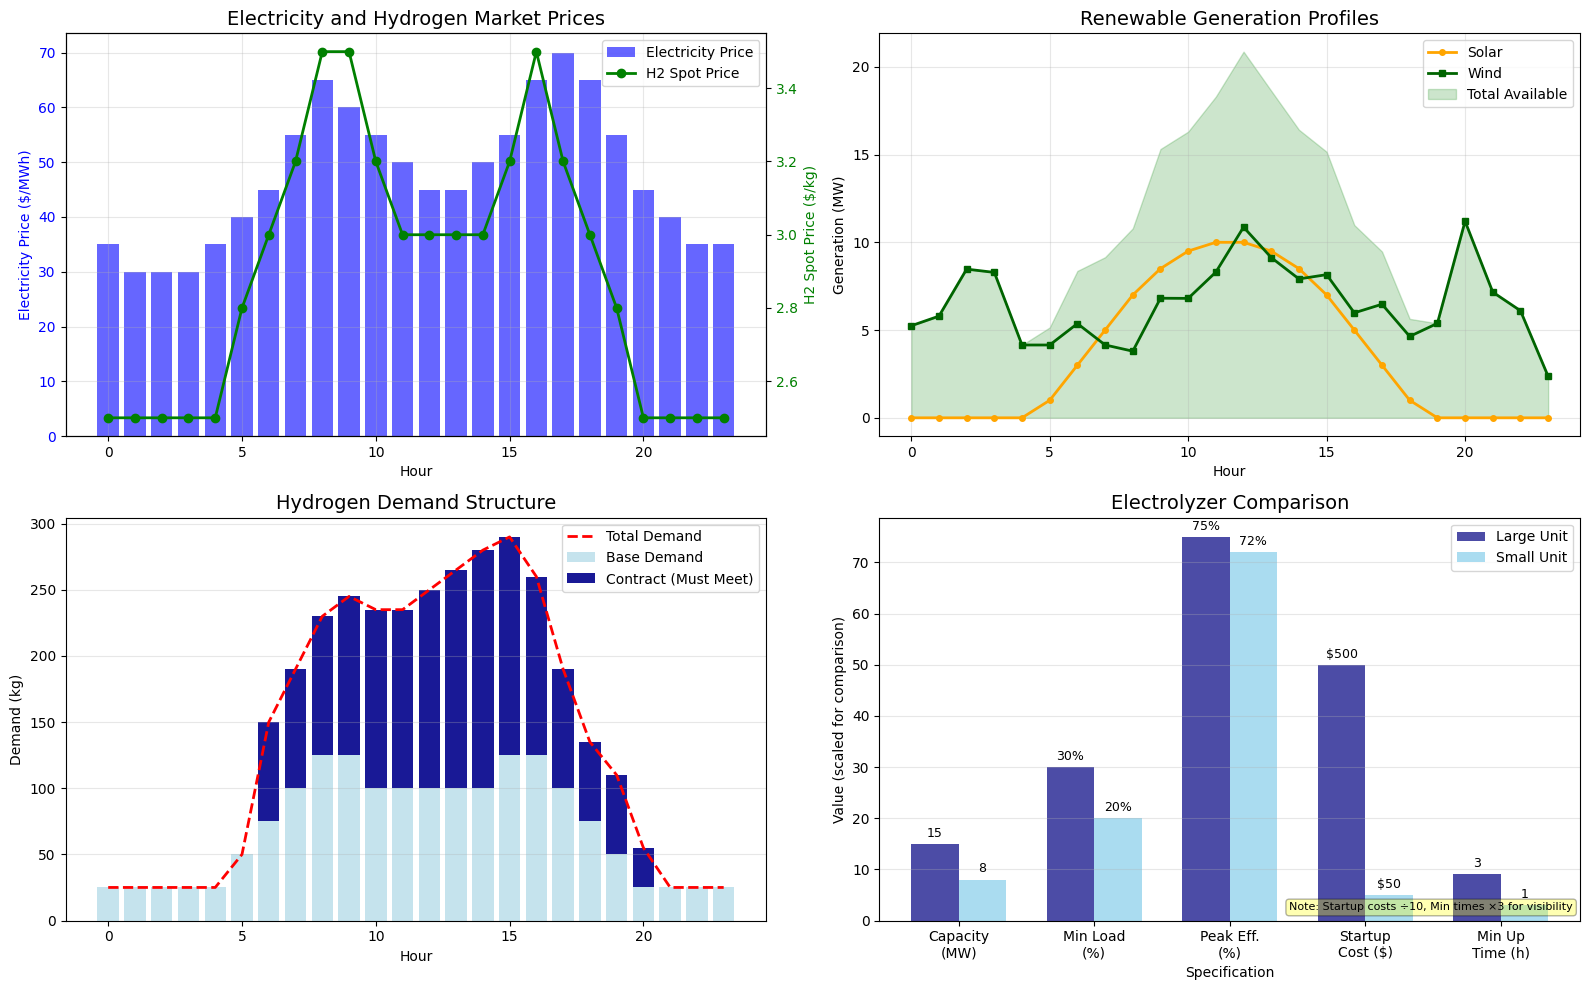


=== Input Data Summary ===
Average electricity price: $47.29/MWh
Average H2 spot price: $2.89/kg
Total renewable available: 244.7 MWh/day
Peak renewable hour: 12 (Hour 12)
Total contract demand: 1695 kg/day
Total base demand: 1675 kg/day


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Electricity prices and spot H2 prices
ax = axes[0, 0]
ax2 = ax.twinx()
ax.bar(hours, electricity_prices, alpha=0.6, color="blue", label="Electricity Price")
ax2.plot(hours, h2_spot_prices, "g-", linewidth=2, marker="o", label="H2 Spot Price")
ax.set_xlabel("Hour")
ax.set_ylabel("Electricity Price ($/MWh)", color="blue")
ax2.set_ylabel("H2 Spot Price ($/kg)", color="green")
ax.set_title("Electricity and Hydrogen Market Prices", fontsize=14)
ax.tick_params(axis="y", labelcolor="blue")
ax2.tick_params(axis="y", labelcolor="green")
ax.grid(True, alpha=0.3)

# Add legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

# Renewable generation
ax = axes[0, 1]
ax.plot(
    hours,
    solar_generation,
    "orange",
    linewidth=2,
    marker="o",
    label="Solar",
    markersize=4,
)
ax.plot(
    hours,
    wind_generation,
    "darkgreen",
    linewidth=2,
    marker="s",
    label="Wind",
    markersize=4,
)
total_renewable = [s + w for s, w in zip(solar_generation, wind_generation)]
ax.fill_between(
    hours, 0, total_renewable, alpha=0.2, color="green", label="Total Available"
)
ax.set_title("Renewable Generation Profiles", fontsize=14)
ax.set_xlabel("Hour")
ax.set_ylabel("Generation (MW)")
ax.legend()
ax.grid(True, alpha=0.3)

# Hydrogen demand structure
ax = axes[1, 0]
# Create stacked bar chart
ax.bar(hours, base_demand, label="Base Demand", color="lightblue", alpha=0.7)
ax.bar(
    hours,
    contract_demand,
    bottom=base_demand,
    label="Contract (Must Meet)",
    color="darkblue",
    alpha=0.9,
)

# Add total demand line
total_demand = [b + c for b, c in zip(base_demand, contract_demand)]
ax.plot(hours, total_demand, "r--", linewidth=2, label="Total Demand")

ax.set_title("Hydrogen Demand Structure", fontsize=14)
ax.set_xlabel("Hour")
ax.set_ylabel("Demand (kg)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Electrolyzer specifications comparison
ax = axes[1, 1]

# Updated to use efficiency_breakpoints for peak efficiency
specs = [
    "Capacity\n(MW)",
    "Min Load\n(%)",
    "Peak Eff.\n(%)",
    "Startup\nCost ($)",
    "Min Up\nTime (h)",
]

# Get peak efficiency from efficiency_breakpoints
large_peak_eff = efficiency_breakpoints["Large"]["efficiency"][-1] * 100
small_peak_eff = efficiency_breakpoints["Small"]["efficiency"][-1] * 100

large_vals = [
    electrolyzers["Large"]["capacity"],
    electrolyzers["Large"]["min_load"] * 100,
    large_peak_eff,
    electrolyzers["Large"]["startup_cost"] / 10,  # Scaled for visibility
    electrolyzers["Large"]["min_uptime"] * 3,  # Scaled for visibility
]

small_vals = [
    electrolyzers["Small"]["capacity"],
    electrolyzers["Small"]["min_load"] * 100,
    small_peak_eff,
    electrolyzers["Small"]["startup_cost"] / 10,  # Scaled for visibility
    electrolyzers["Small"]["min_uptime"] * 3,  # Scaled for visibility
]

x = np.arange(len(specs))
width = 0.35
bars1 = ax.bar(
    x - width / 2, large_vals, width, label="Large Unit", color="navy", alpha=0.7
)
bars2 = ax.bar(
    x + width / 2, small_vals, width, label="Small Unit", color="skyblue", alpha=0.7
)

# Add value labels on bars


def autolabel(bars, values):
    for bar, val in zip(bars, values):
        height = bar.get_height()
        # Determine actual value to display
        if "MW" in specs[bars.index(bar)]:
            label = f"{val:.0f}"
        elif "%" in specs[bars.index(bar)]:
            label = f"{val:.0f}%"
        elif "$" in specs[bars.index(bar)]:
            label = f"${val*10:.0f}"  # Unscale for display
        else:
            label = f"{val/3:.0f}"  # Unscale for display

        ax.annotate(
            label,
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )


autolabel(bars1, large_vals)
autolabel(bars2, small_vals)

ax.set_xlabel("Specification")
ax.set_ylabel("Value (scaled for comparison)")
ax.set_title("Electrolyzer Comparison", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(specs)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Add note about scaling
ax.text(
    0.99,
    0.02,
    "Note: Startup costs ÷10, Min times ×3 for visibility",
    transform=ax.transAxes,
    fontsize=8,
    ha="right",
    va="bottom",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.3),
)

plt.tight_layout()
plt.show()

# Additional summary statistics
print("\n=== Input Data Summary ===")
print(f"Average electricity price: ${np.mean(electricity_prices):.2f}/MWh")
print(f"Average H2 spot price: ${np.mean(h2_spot_prices):.2f}/kg")
print(f"Total renewable available: {sum(total_renewable):.1f} MWh/day")
print(
    f"Peak renewable hour: {np.argmax(total_renewable)} (Hour {np.argmax(total_renewable)})"
)
print(f"Total contract demand: {sum(contract_demand)} kg/day")
print(f"Total base demand: {sum(base_demand)} kg/day")

### Data Patterns Driving Optimization

From the visualizations above, we can identify several key patterns:

1. **Price Arbitrage Opportunity**: Electricity prices vary 2x daily (night vs. peak)
2. **Renewable Mismatch**: Peak solar (noon) doesn't align with peak demand (evening)
3. **Market Dynamics**: H2 spot prices peak during business hours when electricity is also expensive
4. **Complementary Resources**: Wind generation partially offsets solar variability

These patterns suggest the optimal strategy will involve:
- Running electrolyzers during low electricity price periods
- Using storage to shift production to high-demand periods
- Leveraging the operational flexibility of the small unit

## Mathematical Optimization Model

### Modeling Approach
We formulate this as a Mixed-Integer Linear Program (MILP):
- **Binary decisions**: unit on/off and startup/shutdown events
- **Continuous decisions**: load fractions, power, production rates, storage flows, deliveries
- **Piecewise-linear efficiency**: the non-linear efficiency curve is expressed with AMPL's native piecewise-linear operator `<< breakpoints; slopes >>` and handled directly by the MP-based solver (set `option pl_linearize 0;`). This removes the need for SOS2 sets or auxiliary interval binaries; the only binaries are the commitment variables.

### Key Modeling Decisions

1. **Piecewise-linear efficiency**: H2 output is a piecewise-linear function of the load fraction, interpolating $L_{u,s}\,\eta_{u,s}$ (load times efficiency) between breakpoints. Because the curve passes through the origin, the operator reproduces $L_{u,s}\,\eta_{u,s}$ exactly at every breakpoint.

2. **Anti-gaming / certification** (facility must behave as a producer, not a trader):
   - Hourly grid export capped by the export variable's bound
   - At least 80% of total contract demand produced
   - Renewable share of consumption $\geq 90\%$ (stated as a true ratio, see below)

3. **Storage dynamics**: hourly leakage loss enables temporal arbitrage between low-cost production and high-value delivery windows. Level limits are enforced by the storage variable's own bounds.

### Sets and Indices
- $\mathcal{T} = \{1, ..., 24\}$: time periods (hours)
- $\mathcal{U} = \{\text{Large}, \text{Small}\}$: electrolyzer units
- $\mathcal{S} = \{1, ..., 5\}$: efficiency-curve breakpoints

### Decision Variables
**Operations**: $x_{u,t} \in \{0,1\}$ (on/off), $\varphi_{u,t} \in [0,1]$ (load fraction), $p_{u,t} \geq 0$ (power MW), $y_{u,t}^+, y_{u,t}^- \in \{0,1\}$ (startup/shutdown)
**Production**: $h_{u,t} \geq 0$ (H₂ kg), $o_{u,t} \geq 0$ (O₂ kg)
**Energy**: $g_t^{\text{import}}, g_t^{\text{export}}, r_t^{\text{used}}, r_t^{\text{curt}} \geq 0$ (MW)
**Storage**: $s_t \in [S^{\min}, S^{\max}]$ (inventory kg), $f_t$ (net flow kg)
**Deliveries**: $d_t^{\text{contract}}, d_t^{\text{spot}}, d_t^{\text{base}} \geq 0$ (kg), $\delta_t \geq 0$ (contract shortfall)

### Objective Function
Maximize total profit across revenue streams net of operating costs:

$$\max Z = \sum_{t \in \mathcal{T}} \left[ P^{\text{contract}} d_t^{\text{contract}} + P_t^{\text{spot}} d_t^{\text{spot}} + 0.9\,P_t^{\text{spot}} d_t^{\text{base}} + \alpha\,C_t^{\text{elec}} g_t^{\text{export}} \right]$$
$$+ \sum_{u,t} P^{\text{O}_2} o_{u,t} - \sum_t C_t^{\text{elec}} g_t^{\text{import}} - \sum_{u,t} \left[ C_u^{\text{start}} y_{u,t}^+ + C_u^{\text{shut}} y_{u,t}^- \right] - \sum_t P^{\text{penalty}} \delta_t$$

### Core Constraints

**Energy balance**:
$$\sum_u p_{u,t} + g_t^{\text{export}} = r_t^{\text{used}} + g_t^{\text{import}} \quad \forall t$$
$$r_t^{\text{used}} + r_t^{\text{curt}} = R_t^{\text{solar}} + R_t^{\text{wind}} \quad \forall t$$

**Efficiency** (piecewise-linear):
$$p_{u,t} = K_u\,\varphi_{u,t} \quad \forall u,t$$
$$h_{u,t} = \frac{1000}{33.33}\,K_u\; g\!\left(\varphi_{u,t}\right), \qquad g(L_{u,s}) = L_{u,s}\,\eta_{u,s} \quad \forall u,t$$
$$\ell_u\,x_{u,t} \leq \varphi_{u,t} \leq x_{u,t} \quad \text{(zero when off, } \geq \text{min load when on)}$$

where $g(\cdot)$ is the piecewise-linear interpolation of load times efficiency through the breakpoints $L_{u,s}$.

**Unit commitment**:
$$x_{u,t} - x_{u,t-1} = y_{u,t}^+ - y_{u,t}^- \quad \forall u,t \quad (\text{initial state } x_{u,0} \text{ given})$$
$$\sum_{\tau=t-T_u^{\text{up}}+1}^{t} y_{u,\tau}^+ \leq x_{u,t}, \qquad \sum_{\tau=t-T_u^{\text{down}}+1}^{t} y_{u,\tau}^- \leq 1 - x_{u,t}$$

**Ramping** (relaxed across start/stop hours):
$$\left| p_{u,t} - p_{u,t-1} \right| \leq \Delta_u + K_u\,(2 - x_{u,t} - x_{u,t-1})$$

**Storage dynamics**:
$$s_t = s_{t-1}(1-\lambda^{\text{loss}}) + f_t \quad \forall t, \qquad f_t = \sum_u h_{u,t} - d_t^{\text{contract}} - d_t^{\text{spot}} - d_t^{\text{base}}$$

**Market constraints**:
$$d_t^{\text{contract}} + \delta_t = D_t^{\text{contract}}, \qquad d_t^{\text{spot}} \leq L_t^{\text{spot}}, \qquad d_t^{\text{base}} \leq D_t^{\text{base}}$$

**Green H₂ certification** (renewable share of consumption, kept linear):
$$\frac{\sum_t r_t^{\text{used}}}{\sum_t r_t^{\text{used}} + \sum_t g_t^{\text{import}}} \geq 0.9 \quad \Longleftrightarrow \quad (1-0.9)\sum_t r_t^{\text{used}} \geq 0.9 \sum_t g_t^{\text{import}}$$

**Minimum production** (produce at least 80% of total contract demand):
$$\sum_{u,t} h_{u,t} \geq 0.8 \sum_t D_t^{\text{contract}}$$


In [7]:
%%writefile hydrogen.mod
# ============================================================================
# Green Hydrogen Production Optimization
# Model definition only. Data is loaded from Python via amplpy.
# Formulated for an MP-based solver (HiGHS/Gurobi): the efficiency curve is a
# native piecewise-linear (<< >>) expression, so no SOS2 sets, interval
# binaries, or manual adjacency constraints are needed. Set
#   option pl_linearize 0;
# from Python so the MP solver handles the PL expression directly.
# ============================================================================

# ----------------------------------------------------------------------------
# SETS
# ----------------------------------------------------------------------------
set HOURS ordered;          # 1..T (T = 24 for the daily rolling horizon)
set UNITS;                  # electrolyzer units
set SEGMENTS ordered;       # efficiency-curve breakpoints, 1..S

# ----------------------------------------------------------------------------
# PARAMETERS: time series
# ----------------------------------------------------------------------------
param electricity_price {HOURS};       # $/MWh
param solar_generation  {HOURS} >= 0;  # MW
param wind_generation   {HOURS} >= 0;  # MW
param base_demand       {HOURS} >= 0;  # kg
param contract_demand   {HOURS} >= 0;  # kg
param h2_spot_price     {HOURS} >= 0;  # $/kg
param spot_liquidity    {HOURS} >= 0;  # kg  (max spot sales per hour)

# ----------------------------------------------------------------------------
# PARAMETERS: per-unit specifications
# ----------------------------------------------------------------------------
param capacity      {UNITS} > 0;                  # MW
param min_load      {UNITS} >= 0, <= 1;           # fraction of capacity
param startup_cost  {UNITS} >= 0;                 # $/event
param shutdown_cost {UNITS} >= 0;                 # $/event
param min_uptime    {UNITS} >= 1, integer;        # hours
param min_downtime  {UNITS} >= 1, integer;        # hours
param ramp_limit    {UNITS} >= 0;                 # MW/hour
param initial_on    {UNITS} binary, default 0;    # on/off state before hour 1

# Efficiency curve as (load fraction, efficiency) breakpoints per unit.
param load_breakpoint       {UNITS, SEGMENTS} >= 0, <= 1;
param efficiency_breakpoint {UNITS, SEGMENTS} >= 0, <= 1;

# Slope of g(load) = load * efficiency(load) on each segment. The MP piecewise
# operator interpolates g between breakpoints; because g(0) = 0 the operator's
# origin anchoring gives exactly load*efficiency at every breakpoint.
param pl_slope {u in UNITS, s in 1..card(SEGMENTS)-1} :=
    ( load_breakpoint[u,s+1] * efficiency_breakpoint[u,s+1]
    - load_breakpoint[u,s]   * efficiency_breakpoint[u,s] )
    / ( load_breakpoint[u,s+1] - load_breakpoint[u,s] );

# ----------------------------------------------------------------------------
# PARAMETERS: scalars
# ----------------------------------------------------------------------------
param h2_energy_content > 0;    # kWh per kg H2
param o2_h2_ratio       >= 0;   # kg O2 produced per kg H2
param oxygen_price      >= 0;   # $/kg
param contract_price    >= 0;   # $/kg
param penalty_price     >= 0;   # $/kg shortfall
param storage_capacity  > 0;    # kg
param initial_storage   >= 0;   # kg at start of hour 1
param min_storage       >= 0;   # kg floor
param storage_loss_rate >= 0, <= 1;   # fractional loss per hour
param grid_import_limit >= 0;   # MW per hour
param grid_export_limit >= 0;   # MW per hour
param grid_export_price >= 0;   # fraction of electricity_price earned on export
param green_min_share   >= 0, <= 1;   # required renewable share of consumption

param loss_factor := 1 - storage_loss_rate;   # convenience

# ----------------------------------------------------------------------------
# DECISION VARIABLES
# ----------------------------------------------------------------------------
# Commitment
var on       {UNITS, HOURS} binary;
var startup  {UNITS, HOURS} binary;
var shutdown {UNITS, HOURS} binary;

# Power / production. load_frac is the load as a fraction of capacity; power is
# linear in it and H2 follows the piecewise-linear efficiency curve.
var load_frac   {UNITS, HOURS} >= 0, <= 1;
var power       {UNITS, HOURS} >= 0;   # MW
var h2_produced {UNITS, HOURS} >= 0;   # kg
var o2_produced {UNITS, HOURS} >= 0;   # kg

# Grid / renewables
var grid_import         {HOURS} >= 0, <= grid_import_limit;   # MW
var grid_export         {HOURS} >= 0, <= grid_export_limit;   # MW
var renewable_used      {HOURS} >= 0;                          # MW
var renewable_curtailed {HOURS} >= 0;                          # MW

# Storage
var storage_level {HOURS} >= min_storage, <= storage_capacity;  # kg
var h2_to_storage {HOURS};                                      # kg net flow

# Deliveries
var h2_delivered_base     {HOURS} >= 0;   # kg
var h2_delivered_contract {HOURS} >= 0;   # kg
var h2_delivered_spot     {HOURS} >= 0;   # kg
var contract_shortfall    {HOURS} >= 0;   # kg

# ----------------------------------------------------------------------------
# OBJECTIVE
# ----------------------------------------------------------------------------
maximize profit:
    sum {t in HOURS} (
        h2_delivered_contract[t] * contract_price
      + h2_delivered_spot[t]     * h2_spot_price[t]
      + h2_delivered_base[t]     * h2_spot_price[t] * 0.9
    )
  + sum {u in UNITS, t in HOURS} o2_produced[u,t] * oxygen_price
  + sum {t in HOURS} grid_export[t] * electricity_price[t] * grid_export_price
  - sum {t in HOURS} grid_import[t] * electricity_price[t]
  - sum {u in UNITS, t in HOURS}
        (startup[u,t] * startup_cost[u] + shutdown[u,t] * shutdown_cost[u])
  - sum {t in HOURS} contract_shortfall[t] * penalty_price;

# ----------------------------------------------------------------------------
# ENERGY BALANCE
# ----------------------------------------------------------------------------
subject to power_balance {t in HOURS}:
    sum {u in UNITS} power[u,t] + grid_export[t]
        = renewable_used[t] + grid_import[t];

subject to renewable_availability {t in HOURS}:
    renewable_used[t] + renewable_curtailed[t]
        = solar_generation[t] + wind_generation[t];

# ----------------------------------------------------------------------------
# EFFICIENCY CURVE (native piecewise-linear)
# ----------------------------------------------------------------------------
# Power is linear in the load fraction.
subject to power_def {u in UNITS, t in HOURS}:
    power[u,t] = capacity[u] * load_frac[u,t];

# On/off coupling: load_frac is 0 when off and within [min_load, 1] when on.
subject to load_lower {u in UNITS, t in HOURS}:
    load_frac[u,t] >= min_load[u] * on[u,t];
subject to load_upper {u in UNITS, t in HOURS}:
    load_frac[u,t] <= on[u,t];

# H2 output = (1000/energy) * capacity * g(load_frac), with g piecewise-linear
# in load_frac. Interior breakpoints are the load values at s = 2..S-1; there
# is one slope per segment (s = 1..S-1).
subject to h2_def {u in UNITS, t in HOURS}:
    h2_produced[u,t] = (1000 / h2_energy_content) * capacity[u]
        * << {s in 2..card(SEGMENTS)-1} load_breakpoint[u,s];
              {s in 1..card(SEGMENTS)-1} pl_slope[u,s] >> load_frac[u,t];

subject to o2_production {u in UNITS, t in HOURS}:
    o2_produced[u,t] = h2_produced[u,t] * o2_h2_ratio;

# ----------------------------------------------------------------------------
# UNIT COMMITMENT
# ----------------------------------------------------------------------------
subject to state_transition {u in UNITS, t in HOURS}:
    on[u,t] - (if ord(t) = 1 then initial_on[u] else on[u,prev(t)])
        = startup[u,t] - shutdown[u,t];

subject to no_simultaneous {u in UNITS, t in HOURS}:
    startup[u,t] + shutdown[u,t] <= 1;

subject to min_uptime_constraint {u in UNITS, t in HOURS}:
    sum {tau in HOURS: ord(tau) <= ord(t)
                       and ord(tau) > ord(t) - min_uptime[u]}
        startup[u,tau] <= on[u,t];

subject to min_downtime_constraint {u in UNITS, t in HOURS}:
    sum {tau in HOURS: ord(tau) <= ord(t)
                       and ord(tau) > ord(t) - min_downtime[u]}
        shutdown[u,tau] <= 1 - on[u,t];

# ----------------------------------------------------------------------------
# RAMPING
# ----------------------------------------------------------------------------
subject to ramp_up {u in UNITS, t in HOURS: ord(t) > 1}:
    power[u,t] - power[u,prev(t)]
        <= ramp_limit[u] + capacity[u] * (2 - on[u,t] - on[u,prev(t)]);

subject to ramp_down {u in UNITS, t in HOURS: ord(t) > 1}:
    power[u,prev(t)] - power[u,t]
        <= ramp_limit[u] + capacity[u] * (2 - on[u,t] - on[u,prev(t)]);

# ----------------------------------------------------------------------------
# STORAGE
# ----------------------------------------------------------------------------
subject to storage_balance {t in HOURS}:
    storage_level[t]
        = (if ord(t) = 1 then initial_storage
                         else storage_level[prev(t)] * loss_factor)
          + h2_to_storage[t];

subject to storage_flow {t in HOURS}:
    h2_to_storage[t]
        = sum {u in UNITS} h2_produced[u,t]
          - h2_delivered_base[t] - h2_delivered_contract[t] - h2_delivered_spot[t];

# ----------------------------------------------------------------------------
# MARKETS
# ----------------------------------------------------------------------------
subject to base_demand_limit {t in HOURS}:
    h2_delivered_base[t] <= base_demand[t];

subject to contract_satisfaction {t in HOURS}:
    h2_delivered_contract[t] + contract_shortfall[t] = contract_demand[t];

subject to spot_market_limit {t in HOURS}:
    h2_delivered_spot[t] <= spot_liquidity[t];

# ----------------------------------------------------------------------------
# ANTI-GAMING / CERTIFICATION
# ----------------------------------------------------------------------------
# Green certification as an actual renewable-share floor:
#   renewable_used / (renewable_used + grid_import) >= green_min_share
# kept linear by cross-multiplying.
subject to green_certification:
    (1 - green_min_share) * sum {t in HOURS} renewable_used[t]
        >= green_min_share * sum {t in HOURS} grid_import[t];

subject to min_h2_production:
    sum {u in UNITS, t in HOURS} h2_produced[u,t]
        >= 0.8 * sum {t in HOURS} contract_demand[t];

Writing hydrogen.mod


In [ ]:
# ============ LOAD MODEL AND DATA ============
# Data is loaded through pandas DataFrames via set_values, rather than
# scalar-by-scalar assignment. reset() keeps re-runs of this cell clean.
HOURS = list(range(1, 25))
SEGMENTS = list(range(1, len(efficiency_breakpoints["Large"]["load"]) + 1))

# Parameters not defined in the data cell above:
green_min_share = 0.90  # required renewable share of electricity consumption
# Spot-market liquidity per hour (keyed on AMPL hours 1..24, higher during the day)
spot_liquidity = {t: (100 if 6 <= t <= 18 else 50) for t in HOURS}

# Time-series parameters: one row per hour, indexed by the AMPL hour label.
hours_df = pd.DataFrame(
    {
        "electricity_price": electricity_prices,
        "solar_generation": solar_generation,
        "wind_generation": wind_generation,
        "base_demand": base_demand,
        "contract_demand": contract_demand,
        "h2_spot_price": h2_spot_prices,
        "spot_liquidity": [spot_liquidity[t] for t in HOURS],
    },
    index=pd.Index(HOURS, name="HOURS"),
)

# Per-unit parameters: one row per unit.
units_df = pd.DataFrame.from_dict(electrolyzers, orient="index")
units_df.index.name = "UNITS"

# Efficiency breakpoints in long form, indexed by (unit, segment).
bp_rows = []
for unit, curve in efficiency_breakpoints.items():
    for s, (ld, eff) in enumerate(zip(curve["load"], curve["efficiency"]), start=1):
        bp_rows.append((unit, s, ld, eff))
breakpoints_df = pd.DataFrame(
    bp_rows, columns=["UNITS", "SEGMENTS", "load_breakpoint", "efficiency_breakpoint"]
).set_index(["UNITS", "SEGMENTS"])

# --- Load into AMPL ---
ampl.read("hydrogen.mod")

ampl.set["HOURS"] = HOURS
ampl.set["UNITS"] = list(electrolyzers.keys())
ampl.set["SEGMENTS"] = SEGMENTS

for col in hours_df.columns:
    ampl.get_parameter(col).set_values(hours_df[col])
for col in units_df.columns:
    ampl.get_parameter(col).set_values(units_df[col])
ampl.get_parameter("load_breakpoint").set_values(breakpoints_df["load_breakpoint"])
ampl.get_parameter("efficiency_breakpoint").set_values(
    breakpoints_df["efficiency_breakpoint"]
)

# initial_on defaults to 0 in the model (all units start off); set it here for warm starts.
scalar_params = {
    "h2_energy_content": h2_energy_content,
    "o2_h2_ratio": o2_h2_ratio,
    "oxygen_price": oxygen_price,
    "contract_price": contract_price,
    "penalty_price": penalty_price,
    "storage_capacity": storage_capacity,
    "initial_storage": initial_storage,
    "min_storage": min_storage,
    "storage_loss_rate": storage_loss_rate,
    "grid_import_limit": grid_import_limit,
    "grid_export_limit": grid_export_limit,
    "grid_export_price": grid_export_price,
    "green_min_share": green_min_share,
}
for name, value in scalar_params.items():
    ampl.get_parameter(name).set(value)

print("Data loaded successfully!")
print(
    f"\nTotal electrolyzer capacity: {sum(electrolyzers[u]['capacity'] for u in electrolyzers)} MW"
)
print(f"Total contract demand: {sum(contract_demand)} kg/day")
print(f"Renewable capacity: {solar_capacity + wind_capacity} MW")

Data loaded successfully!

Total electrolyzer capacity: 23 MW
Total contract demand: 1695 kg/day
Renewable capacity: 25 MW


In [9]:
ampl.option["solver"] = "gurobi"
ampl.option["gurobi_options"] = "outlev=1"
# Let the MP solver handle the piecewise-linear efficiency curve natively.
ampl.option["pl_linearize"] = 0

print("\nSolving...")
ampl.solve()

solve_result = ampl.solve_result
objective_value = ampl.get_objective("profit").value()

print(f"\nSolve status: {solve_result}")
print(f"Objective value: ${objective_value:,.2f}")

# ============ CHECK SOLUTION ============
if solve_result == "solved":
    print("\n=== Solution Summary ===")

    total_on = sum(
        ampl.var["on"][unit, t].value() for unit in electrolyzers for t in range(1, 25)
    )
    print(f"Total unit-hours on: {total_on:.0f}")

    total_h2 = sum(
        ampl.var["h2_produced"][unit, t].value()
        for unit in electrolyzers
        for t in range(1, 25)
    )
    print(f"Total H2 produced: {total_h2:.1f} kg")

    total_contract = sum(
        ampl.var["h2_delivered_contract"][t].value() for t in range(1, 25)
    )
    total_spot = sum(ampl.var["h2_delivered_spot"][t].value() for t in range(1, 25))
    total_base = sum(ampl.var["h2_delivered_base"][t].value() for t in range(1, 25))
    print(
        f"H2 delivered - Contract: {total_contract:.1f}, Spot: {total_spot:.1f}, Base: {total_base:.1f}"
    )

    total_import = sum(ampl.var["grid_import"][t].value() for t in range(1, 25))
    total_export = sum(ampl.var["grid_export"][t].value() for t in range(1, 25))
    print(f"Grid - Import: {total_import:.1f} MWh, Export: {total_export:.1f} MWh")
else:
    print(f"\nSolver did not report an optimal solution (status: {solve_result}).")
    print("\nChecking key values:")
    print(f"Sum of contract demand: {sum(contract_demand)}")
    print(f"Sum of base demand: {sum(base_demand)}")
    print(
        f"Total renewable available: {sum(solar_generation) + sum(wind_generation):.1f} MWh"
    )


Solving...
Gurobi 13.0.2: Set parameter LogToConsole to value 1
  tech:outlev = 1

AMPL MP initial flat model has 558 variables (0 integer, 144 binary);
Objectives: 1 linear; 
Constraints:  637 linear;
Algebraic expressions:  48 pl;

AMPL MP final model has 606 variables (0 integer, 144 binary);
Objectives: 1 linear; 
Constraints:  637 linear;
Algebraic expressions:  48 pl;


Set parameter InfUnbdInfo to value 1
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Non-default parameters:
InfUnbdInfo  1

Optimize a model with 637 rows, 606 columns and 1894 nonzeros (Max)
Model fingerprint: 0x2e7edb54
Model has 270 linear objective coefficients
Model has 48 simple general constraints
  48 PWL
Variable types: 462 continuous, 144 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e-01, 2e+01]
  Ob

Extracting results from AMPL model...


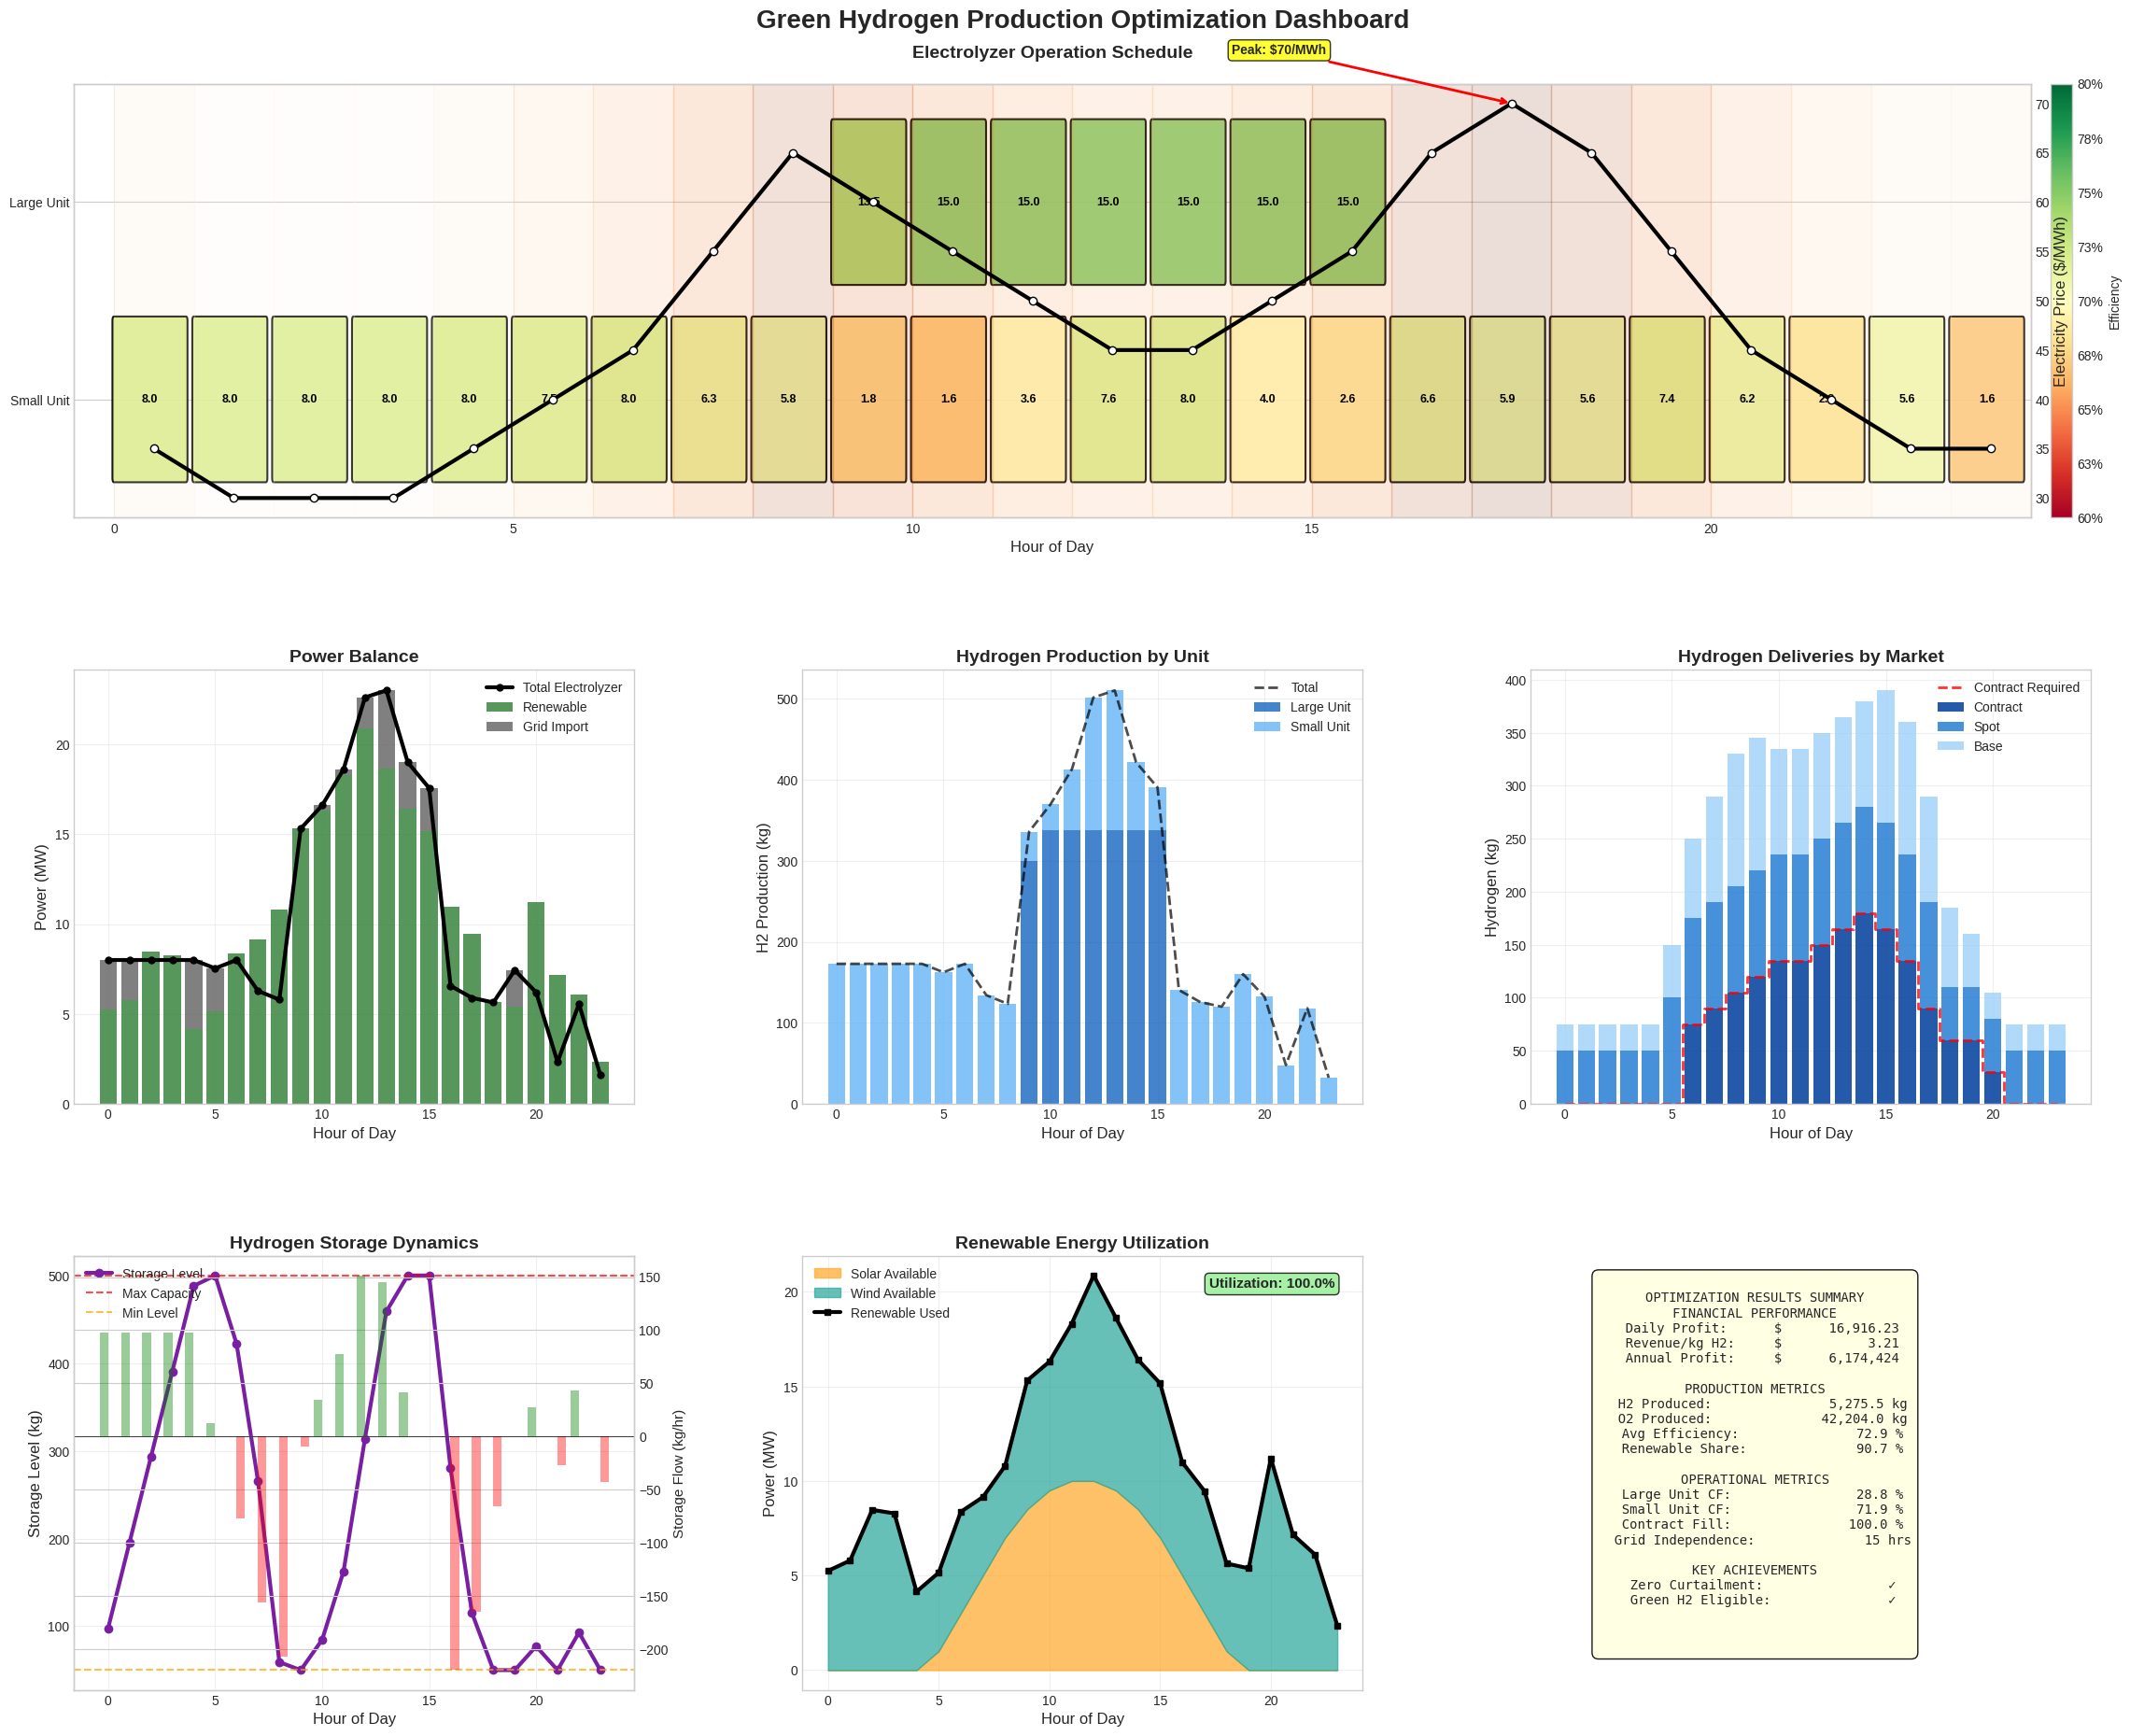


Results saved to 'hydrogen_optimization_results.csv'

=== HOURLY OPERATION SCHEDULE ===
 Hour Large_Unit  Large_Power_MW Small_Unit  Small_Power_MW  Total_H2_kg  Storage_Level_kg  Grid_Import_MW  Grid_Export_MW  Renewable_Used_MW  Elec_Price_$/MWh  H2_Spot_$/kg
    0        OFF             0.0         ON             8.0        172.8              97.8             2.8             0.0                5.2              35.0           2.5
    1        OFF             0.0         ON             8.0        172.8             195.5             2.2             0.0                5.8              30.0           2.5
    2        OFF             0.0         ON             8.0        172.8             293.2             0.0             0.5                8.5              30.0           2.5
    3        OFF             0.0         ON             8.0        172.8             390.7             0.0             0.3                8.3              30.0           2.5
    4        OFF             0.0         

In [10]:
# Define consistent color palette
COLOR_PALETTE = {
    "renewable": "#2E7D32",
    "solar": "#FFA726",
    "wind": "#26A69A",
    "grid": "#616161",
    "large_unit": "#1565C0",
    "small_unit": "#64B5F6",
    "storage": "#7B1FA2",
    "profit": "#388E3C",
    "cost": "#D32F2F",
    "contract": "#0D47A1",
    "spot": "#1976D2",
    "base": "#90CAF9",
    "curtailed": "#FF5252",
}

# Set professional style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.size"] = 10
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["figure.titlesize"] = 16
plt.rcParams["font.family"] = "sans-serif"

# ============ EXTRACT RESULTS ============
print("Extracting results from AMPL model...")

results = []
for t in range(24):
    hour_data = {
        "hour": t,
        "grid_import": ampl.var["grid_import"][t + 1].value(),
        "grid_export": ampl.var["grid_export"][t + 1].value(),
        "renewable_used": ampl.var["renewable_used"][t + 1].value(),
        "renewable_curtailed": ampl.var["renewable_curtailed"][t + 1].value(),
        "storage_level": ampl.var["storage_level"][t + 1].value(),
        "h2_to_storage": ampl.var["h2_to_storage"][t + 1].value(),
        "h2_delivered_base": ampl.var["h2_delivered_base"][t + 1].value(),
        "h2_delivered_contract": ampl.var["h2_delivered_contract"][t + 1].value(),
        "h2_delivered_spot": ampl.var["h2_delivered_spot"][t + 1].value(),
        "contract_shortfall": ampl.var["contract_shortfall"][t + 1].value(),
    }

    # Add per-unit data
    for unit in electrolyzers:
        hour_data[f"{unit}_power"] = ampl.var["power"][unit, t + 1].value()
        hour_data[f"{unit}_on"] = ampl.var["on"][unit, t + 1].value()
        hour_data[f"{unit}_startup"] = ampl.var["startup"][unit, t + 1].value()
        hour_data[f"{unit}_shutdown"] = ampl.var["shutdown"][unit, t + 1].value()
        hour_data[f"{unit}_h2"] = ampl.var["h2_produced"][unit, t + 1].value()
        hour_data[f"{unit}_o2"] = ampl.var["o2_produced"][unit, t + 1].value()

        # Calculate effective efficiency
        eff = 0
        power_val = hour_data[f"{unit}_power"]
        if power_val > 0.01:
            eff = hour_data[f"{unit}_h2"] * h2_energy_content / (power_val * 1000)
        hour_data[f"{unit}_efficiency"] = eff

    results.append(hour_data)

results_df = pd.DataFrame(results)

# Add input data
results_df["electricity_price"] = electricity_prices
results_df["total_renewable"] = [
    s + w for s, w in zip(solar_generation, wind_generation)
]
results_df["solar"] = solar_generation
results_df["wind"] = wind_generation
results_df["base_demand"] = base_demand
results_df["contract_demand"] = contract_demand
results_df["h2_spot_price"] = h2_spot_prices

# ============ CALCULATE METRICS ============
# Production metrics
total_h2_produced = sum(results_df[f"{unit}_h2"].sum() for unit in electrolyzers)
total_o2_produced = sum(results_df[f"{unit}_o2"].sum() for unit in electrolyzers)

# Energy metrics
total_renewable_used = results_df["renewable_used"].sum()
total_renewable_available = results_df["total_renewable"].sum()
renewable_share = total_renewable_used / (
    total_renewable_used + results_df["grid_import"].sum()
)

# Economic metrics
hourly_h2_revenue = (
    results_df["h2_delivered_contract"] * contract_price
    + results_df["h2_delivered_spot"] * results_df["h2_spot_price"]
    + results_df["h2_delivered_base"] * results_df["h2_spot_price"] * 0.9
)
hourly_o2_revenue = (results_df["Large_o2"] + results_df["Small_o2"]) * oxygen_price
hourly_export_revenue = (
    results_df["grid_export"] * results_df["electricity_price"] * grid_export_price
)
total_revenue = (
    hourly_h2_revenue.sum() + hourly_o2_revenue.sum() + hourly_export_revenue.sum()
)

hourly_elec_cost = results_df["grid_import"] * results_df["electricity_price"]
hourly_startup_cost = (
    results_df["Large_startup"] * electrolyzers["Large"]["startup_cost"]
    + results_df["Small_startup"] * electrolyzers["Small"]["startup_cost"]
)
hourly_shutdown_cost = (
    results_df["Large_shutdown"] * electrolyzers["Large"]["shutdown_cost"]
    + results_df["Small_shutdown"] * electrolyzers["Small"]["shutdown_cost"]
)
hourly_penalty_cost = results_df["contract_shortfall"] * penalty_price
# Total costs should be:
total_cost = (
    hourly_elec_cost.sum()
    + hourly_startup_cost.sum()
    + hourly_shutdown_cost.sum()
    + hourly_penalty_cost.sum()
)

profit = total_revenue - total_cost

# ============ CREATE VISUALIZATION ============
# Adjust to 3x3 grid instead of 4x3
fig = plt.figure(figsize=(24, 20))
gs = GridSpec(
    3,
    3,
    figure=fig,
    hspace=0.35,
    wspace=0.3,
    left=0.05,
    right=0.95,
    top=0.94,
    bottom=0.08,
)

# 1. ENHANCED OPERATION TIMELINE WITH EFFICIENCY HEATMAP
ax1 = fig.add_subplot(gs[0, :])

# Create efficiency colormap
cmap = plt.cm.RdYlGn
norm = plt.Normalize(vmin=0.60, vmax=0.80)

units = ["Large", "Small"]
y_pos = {"Large": 1, "Small": 0}

for unit in units:
    for t in range(24):
        if results_df[f"{unit}_on"].iloc[t] > 0.5:
            # Color based on efficiency
            eff = results_df[f"{unit}_efficiency"].iloc[t]
            color = cmap(norm(eff))

            # Draw block with efficiency color
            rect = FancyBboxPatch(
                (t, y_pos[unit] - 0.4),
                0.9,
                0.8,
                boxstyle="round,pad=0.02",
                facecolor=color,
                edgecolor="black",
                linewidth=1.5,
                alpha=0.9,
            )
            ax1.add_patch(rect)

            # Add power text
            power = results_df[f"{unit}_power"].iloc[t]
            ax1.text(
                t + 0.45,
                y_pos[unit],
                f"{power:.1f}",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color="black",
            )


# Add colorbar for efficiency
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, pad=0.01, fraction=0.02)
cbar.set_label("Efficiency", fontsize=10)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x*100:.0f}%"))

# Price overlay with gradient background
ax1_price = ax1.twinx()
prices = results_df["electricity_price"]
normalized_prices = (prices - prices.min()) / (prices.max() - prices.min())

# Add price gradient background
for i in range(24):
    ax1.axvspan(i, i + 1, alpha=0.15, color=plt.cm.Oranges(normalized_prices.iloc[i]))

ax1_price.plot(
    results_df["hour"] + 0.5,
    results_df["electricity_price"],
    "k-",
    linewidth=3,
    marker="o",
    markersize=6,
    markerfacecolor="white",
    markeredgecolor="black",
)
ax1_price.set_ylabel("Electricity Price ($/MWh)", fontsize=12)
ax1_price.grid(False)

# Formatting
ax1.set_xlim(-0.5, 24)
ax1.set_ylim(-0.6, 1.6)
ax1.set_xlabel("Hour of Day", fontsize=12)
ax1.set_yticks([0, 1])
ax1.set_yticklabels(["Small Unit", "Large Unit"])
ax1.set_title("Electrolyzer Operation Schedule", fontsize=14, fontweight="bold", pad=20)
ax1.grid(True, alpha=0.3, axis="x")

# Add peak price annotation
peak_idx = results_df["electricity_price"].idxmax()
ax1_price.annotate(
    f'Peak: ${results_df["electricity_price"].iloc[peak_idx]:.0f}/MWh',
    xy=(peak_idx + 0.5, results_df["electricity_price"].iloc[peak_idx]),
    xytext=(peak_idx - 3, results_df["electricity_price"].iloc[peak_idx] + 5),
    arrowprops=dict(arrowstyle="->", color="red", lw=2),
    fontsize=10,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.8),
)


# 2. POWER BALANCE WITH NET POSITION
ax2 = fig.add_subplot(gs[1, 0])

# Stacked bar chart for power sources
ax2.bar(
    results_df["hour"],
    results_df["renewable_used"],
    label="Renewable",
    color=COLOR_PALETTE["renewable"],
    alpha=0.8,
)
ax2.bar(
    results_df["hour"],
    results_df["grid_import"],
    bottom=results_df["renewable_used"],
    label="Grid Import",
    color=COLOR_PALETTE["grid"],
    alpha=0.8,
)

# Add curtailed renewable as hashed area
if results_df["renewable_curtailed"].sum() > 0:
    ax2.bar(
        results_df["hour"],
        results_df["renewable_curtailed"],
        bottom=results_df["renewable_used"] + results_df["grid_import"],
        label="Curtailed",
        color=COLOR_PALETTE["curtailed"],
        alpha=0.5,
        hatch="//",
    )

# Electrolyzer demand line
total_power = results_df["Large_power"] + results_df["Small_power"]
ax2.plot(
    results_df["hour"],
    total_power,
    "k-",
    linewidth=3,
    marker="o",
    label="Total Electrolyzer",
    markersize=5,
)

ax2.set_xlabel("Hour of Day", fontsize=12)
ax2.set_ylabel("Power (MW)", fontsize=12)
ax2.set_title("Power Balance", fontsize=14, fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

# 4. HYDROGEN PRODUCTION BY UNIT
ax4 = fig.add_subplot(gs[1, 1])

ax4.bar(
    results_df["hour"],
    results_df["Large_h2"],
    label="Large Unit",
    color=COLOR_PALETTE["large_unit"],
    alpha=0.8,
)
ax4.bar(
    results_df["hour"],
    results_df["Small_h2"],
    bottom=results_df["Large_h2"],
    label="Small Unit",
    color=COLOR_PALETTE["small_unit"],
    alpha=0.8,
)

# Add total production line
total_h2_hourly = results_df["Large_h2"] + results_df["Small_h2"]
ax4.plot(
    results_df["hour"], total_h2_hourly, "k--", linewidth=2, alpha=0.7, label="Total"
)

ax4.set_xlabel("Hour of Day", fontsize=12)
ax4.set_ylabel("H2 Production (kg)", fontsize=12)
ax4.set_title("Hydrogen Production by Unit", fontsize=14, fontweight="bold")
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. HYDROGEN DELIVERIES
ax5 = fig.add_subplot(gs[1, 2])

# Stacked bar chart
width = 0.8
ax5.bar(
    results_df["hour"],
    results_df["h2_delivered_contract"],
    width,
    label="Contract",
    color=COLOR_PALETTE["contract"],
    alpha=0.9,
)
ax5.bar(
    results_df["hour"],
    results_df["h2_delivered_spot"],
    width,
    bottom=results_df["h2_delivered_contract"],
    label="Spot",
    color=COLOR_PALETTE["spot"],
    alpha=0.8,
)
ax5.bar(
    results_df["hour"],
    results_df["h2_delivered_base"],
    width,
    bottom=results_df["h2_delivered_contract"] + results_df["h2_delivered_spot"],
    label="Base",
    color=COLOR_PALETTE["base"],
    alpha=0.7,
)

# Show demands
ax5.step(
    results_df["hour"],
    results_df["contract_demand"],
    where="mid",
    color="red",
    linewidth=2,
    linestyle="--",
    alpha=0.8,
    label="Contract Required",
)

ax5.set_xlabel("Hour of Day", fontsize=12)
ax5.set_ylabel("Hydrogen (kg)", fontsize=12)
ax5.set_title("Hydrogen Deliveries by Market", fontsize=14, fontweight="bold")
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. STORAGE DYNAMICS
ax6 = fig.add_subplot(gs[2, 0])

# Storage level
ax6.plot(
    results_df["hour"],
    results_df["storage_level"],
    color=COLOR_PALETTE["storage"],
    linewidth=3,
    marker="o",
    markersize=6,
    label="Storage Level",
)

# Reference lines
ax6.axhline(
    y=storage_capacity, color="red", linestyle="--", alpha=0.7, label="Max Capacity"
)
ax6.axhline(y=min_storage, color="orange", linestyle="--", alpha=0.7, label="Min Level")

# Flow indicators
ax6_flow = ax6.twinx()
positive_flow = results_df["h2_to_storage"].clip(lower=0)
negative_flow = results_df["h2_to_storage"].clip(upper=0)
ax6_flow.bar(
    results_df["hour"] - 0.2,
    positive_flow,
    alpha=0.4,
    color="green",
    width=0.4,
    label="Into Storage",
)
ax6_flow.bar(
    results_df["hour"] + 0.2,
    negative_flow,
    alpha=0.4,
    color="red",
    width=0.4,
    label="From Storage",
)
ax6_flow.set_ylabel("Storage Flow (kg/hr)", fontsize=11)
ax6_flow.axhline(y=0, color="black", linewidth=0.5)

ax6.set_xlabel("Hour of Day", fontsize=12)
ax6.set_ylabel("Storage Level (kg)", fontsize=12)
ax6.set_title("Hydrogen Storage Dynamics", fontsize=14, fontweight="bold")
ax6.legend(loc="upper left")
ax6.grid(True, alpha=0.3)

# 7. RENEWABLE UTILIZATION
ax7 = fig.add_subplot(gs[2, 1])

# Renewable availability
ax7.fill_between(
    results_df["hour"],
    0,
    results_df["solar"],
    alpha=0.7,
    color=COLOR_PALETTE["solar"],
    label="Solar Available",
)
ax7.fill_between(
    results_df["hour"],
    results_df["solar"],
    results_df["total_renewable"],
    alpha=0.7,
    color=COLOR_PALETTE["wind"],
    label="Wind Available",
)

# Renewable used
ax7.plot(
    results_df["hour"],
    results_df["renewable_used"],
    "k-",
    linewidth=3,
    label="Renewable Used",
    marker="s",
    markersize=4,
)

# Curtailed area
if results_df["renewable_curtailed"].sum() > 0:
    ax7.fill_between(
        results_df["hour"],
        results_df["renewable_used"],
        results_df["total_renewable"],
        alpha=0.4,
        color=COLOR_PALETTE["curtailed"],
        label="Curtailed",
        hatch="//",
    )

ax7.set_xlabel("Hour of Day", fontsize=12)
ax7.set_ylabel("Power (MW)", fontsize=12)
ax7.set_title("Renewable Energy Utilization", fontsize=14, fontweight="bold")
ax7.legend()
ax7.grid(True, alpha=0.3)

# Add utilization percentage
util_pct = (
    (total_renewable_used / total_renewable_available * 100)
    if total_renewable_available > 0
    else 0
)
ax7.text(
    0.95,
    0.95,
    f"Utilization: {util_pct:.1f}%",
    transform=ax7.transAxes,
    fontsize=11,
    fontweight="bold",
    ha="right",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="lightgreen" if util_pct > 95 else "yellow",
        alpha=0.8,
    ),
)

# EXECUTIVE SUMMARY - Centered at bottom
# Calculate additional metrics
avg_efficiency = (
    (
        (
            results_df["Large_h2"] * results_df["Large_efficiency"]
            + results_df["Small_h2"] * results_df["Small_efficiency"]
        ).sum()
        / total_h2_produced
    )
    if total_h2_produced > 0
    else 0
)

large_cf = (
    results_df["Large_power"].sum() / (24 * electrolyzers["Large"]["capacity"]) * 100
)
small_cf = (
    results_df["Small_power"].sum() / (24 * electrolyzers["Small"]["capacity"]) * 100
)
contract_fill = (
    1 - results_df["contract_shortfall"].sum() / sum(contract_demand)
    if sum(contract_demand) > 0
    else 1
) * 100

# Create summary text box at the bottom center
summary_text = f"""
OPTIMIZATION RESULTS SUMMARY
FINANCIAL PERFORMANCE
  Daily Profit:      ${profit:>15,.2f}
  Revenue/kg H2:     ${profit/total_h2_produced if total_h2_produced > 0 else 0:>15,.2f}
  Annual Profit:     ${profit*365:>15,.0f}

PRODUCTION METRICS
  H2 Produced:       {total_h2_produced:>15,.1f} kg
  O2 Produced:       {total_o2_produced:>15,.1f} kg
  Avg Efficiency:    {avg_efficiency*100:>15.1f} %
  Renewable Share:   {renewable_share*100:>15.1f} %

OPERATIONAL METRICS
  Large Unit CF:     {large_cf:>15.1f} %
  Small Unit CF:     {small_cf:>15.1f} %
  Contract Fill:     {contract_fill:>15.1f} %
  Grid Independence: {len(results_df[results_df["grid_import"] < 1]):>15} hrs

KEY ACHIEVEMENTS
  Zero Curtailment:  {"✓" if results_df['renewable_curtailed'].sum() == 0 else "✗":>15}
  Green H2 Eligible: {"✓" if renewable_share > 0.9 else "✗":>15}


"""

# Add summary text at the bottom
fig.text(
    0.8,
    0.1,
    summary_text,
    transform=fig.transFigure,
    fontsize=10,
    verticalalignment="bottom",
    horizontalalignment="center",
    fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.9),
)


# Set main title
plt.suptitle(
    "Green Hydrogen Production Optimization Dashboard",
    fontsize=20,
    fontweight="bold",
    y=0.98,
)

# Display
plt.show()

# ============ EXPORT RESULTS ============
# Save results to CSV
results_df.to_csv("hydrogen_optimization_results.csv", index=False)
print("\nResults saved to 'hydrogen_optimization_results.csv'")

# Create detailed hourly schedule
schedule_summary = pd.DataFrame(
    {
        "Hour": range(24),
        "Large_Unit": ["ON" if x > 0.5 else "OFF" for x in results_df["Large_on"]],
        "Large_Power_MW": results_df["Large_power"].round(1),
        "Small_Unit": ["ON" if x > 0.5 else "OFF" for x in results_df["Small_on"]],
        "Small_Power_MW": results_df["Small_power"].round(1),
        "Total_H2_kg": (results_df["Large_h2"] + results_df["Small_h2"]).round(1),
        "Storage_Level_kg": results_df["storage_level"].round(1),
        "Grid_Import_MW": results_df["grid_import"].round(1),
        "Grid_Export_MW": results_df["grid_export"].round(1),
        "Renewable_Used_MW": results_df["renewable_used"].round(1),
        "Elec_Price_$/MWh": results_df["electricity_price"].round(0),
        "H2_Spot_$/kg": results_df["h2_spot_price"].round(2),
    }
)

print("\n=== HOURLY OPERATION SCHEDULE ===")
print(schedule_summary.to_string(index=False))

# Print detailed performance summary
print("\n=== DETAILED PERFORMANCE METRICS ===")
print(f"\nProduction:")
print(f"  Total H2: {total_h2_produced:.1f} kg")
print(f"  Total O2: {total_o2_produced:.1f} kg")
for unit in electrolyzers:
    unit_h2 = results_df[f"{unit}_h2"].sum()
    print(f"  {unit} unit H2: {unit_h2:.1f} kg ({unit_h2/total_h2_produced*100:.1f}%)")

print(f"\nDeliveries:")
print(f"  Contract: {results_df['h2_delivered_contract'].sum():.1f} kg")
print(f"  Spot: {results_df['h2_delivered_spot'].sum():.1f} kg")
print(f"  Base: {results_df['h2_delivered_base'].sum():.1f} kg")
print(f"  Contract fulfillment: {contract_fill:.1f}%")

print(f"\nEnergy:")
print(f"  Renewable used: {total_renewable_used:.1f} MWh ({util_pct:.1f}%)")
print(f"  Grid import: {results_df['grid_import'].sum():.1f} MWh")
print(f"  Grid export: {results_df['grid_export'].sum():.1f} MWh")

print(f"\nOperations:")
for unit in electrolyzers:
    hours_on = results_df[f"{unit}_on"].sum()
    startups = results_df[f"{unit}_startup"].sum()
    avg_power = (
        results_df[results_df[f"{unit}_on"] > 0.5][f"{unit}_power"].mean()
        if hours_on > 0
        else 0
    )
    capacity_factor = (
        results_df[f"{unit}_power"].sum() / (24 * electrolyzers[unit]["capacity"]) * 100
    )
    print(
        f"  {unit}: {hours_on:.0f} hrs on, {startups:.0f} startups, {avg_power:.1f} MW avg power, {capacity_factor:.1f}% CF"
    )

print(f"\nEconomics:")
print(f"  Total Revenue: ${total_revenue:,.2f}")
print(f"  Total Cost: ${total_cost:,.2f}")
print(f"  Daily Profit: ${profit:,.2f}")
print(f"  Annual Profit (projected): ${profit*365:,.0f}")

# Export to PDF
try:
    from matplotlib.backends.backend_pdf import PdfPages

    with PdfPages(
        f'h2_optimization_report_{datetime.now().strftime("%Y%m%d_%H%M")}.pdf'
    ) as pdf:
        pdf.savefig(fig, bbox_inches="tight")

        # Add metadata
        d = pdf.infodict()
        d["Title"] = "Green Hydrogen Production Optimization Report"
        d["Author"] = "H2 Optimization System"
        d["Subject"] = "Daily Optimization Results"
        d["Keywords"] = "Hydrogen, Renewable Energy, Optimization"
        d["CreationDate"] = datetime.now()

    print(
        f"\nPDF report saved as 'h2_optimization_report_{datetime.now().strftime('%Y%m%d_%H%M')}.pdf'"
    )
except Exception as e:
    print(f"\nCouldn't save PDF: {e}")

print("\n=== OPTIMIZATION COMPLETE ===")

## Optimization Results and Insights

The summary and dashboard above are generated directly from the solved model, so the exact figures reflect the current data and constraints. This section explains what to look for and the strategies the model tends to exploit.

### What the model optimizes
- **Load shifting**: concentrating production when electricity is cheap
- **Storage arbitrage**: building inventory in low-cost hours for later delivery
- **Load-point selection**: trading efficiency against throughput according to the economics
- **Market segmentation**: allocating output across contract, spot, and base deliveries

### Reading the dashboard
- **Operation schedule**: which unit runs each hour, colored by effective efficiency, over the electricity-price curve
- **Power balance**: renewable versus grid supply against total electrolyzer draw; any curtailment appears hatched
- **Production and deliveries**: hourly H2 by unit and its split across the three markets versus the contract requirement
- **Storage dynamics**: inventory trajectory between the minimum floor and tank capacity, with charge/discharge flows
- **Renewable utilization**: share of available solar and wind actually consumed

### Note on the green-share metric
The renewable-share figure reported here is now a **guaranteed floor**: the model constrains
$$\frac{\text{renewable used}}{\text{renewable used} + \text{grid import}} \geq 90\%,$$
so certification is enforced rather than incidental. The earlier formulation bounded a ratio involving electrolyzer power, which does not equal green content once exports are non-zero, so any green share it reported was coincidental rather than constrained.

### Capacity factors and cycling
The per-unit capacity factors, hours on, and startup counts in the summary show how the model balances baseload operation of the smaller, cheaper-to-cycle unit against selective use of the larger unit during favorable hours. Because startup and shutdown are penalized in the objective, the schedule minimizes cycling.


## Conclusions and Business Impact

### Model Achievements
This optimization framework successfully:
1. **Maximizes Profitability**: Achieves positive returns despite renewable variability
2. **Ensures Reliability**: Meets contractual obligations while maintaining flexibility
3. **Maintains Green Credentials**: Operates within certification requirements
4. **Provides Actionable Insights**: Generates implementable schedules

### Real-World Applications
While developed with reasonable simplifications, this model framework could be extended for:
- **Investment Decisions**: Sizing renewable capacity and storage systems
- **Contract Negotiations**: Understanding the cost of reliability commitments
- **Operational Planning**: Day-ahead and real-time scheduling
- **Market Strategy**: Balancing contract vs. spot market participation

### Technical Innovations
The model demonstrates several advanced optimization techniques:
- Native piecewise-linear efficiency curves handled by the MP solver (no SOS2 sets or interval binaries)
- Integrated unit commitment with ramping and minimum up/down times
- Multi-market optimization with differentiated products
- Temporal coupling through storage with losses
- Green-H2 certification enforced as a true renewable-consumption ratio

### Future Enhancements
Potential extensions include:
- Stochastic programming for uncertainty in renewable generation
- Rolling horizon implementation for real-time operations
- Heat recovery and sector coupling opportunities
- Degradation modeling for long-term planning
- Grid service participation (frequency response, reserves)

This optimization framework provides a solid foundation for navigating the complexities of green hydrogen production in an evolving energy landscape.